# Instalacion Solar Interconectada

# Metodo:
1. Estudiar Espacio: superficie disponible y posibilidadesde orientacion, inclinacion en integracion.
2. Energia FV a generar: analizar curva de consumos diurnos o facturas. Determinar el objetivo de generacion.
3. Dimensionar Paneles: segun la necesidad de energia a generar establecida
4. Elegir Inversor y Configurar Modulos: El inversor debe tener entre 80-100% de la potencia del campo solar
5. Calculo del Cableado: se comprobaran secciones por caida de voltaje e intensidad maxima admisible
6. Cuadros y Tratamiento de Exedentes: Proteccion de CC y de CA. Excedentes se limitaran o se verteran a la red.

# Paso 1: Estudiar Espacio

In [1]:
# Segun el analisis del techo del sitio a instalar se tienen dos faldones inclinados 15 grados, y de 3m por 4.5m

# Faldon 1 Medida: 3 m x 7.0 m
# Faldon 1 Inclinacion: 15 grados
# Faldon 1 Azimuth: 116.23 grados
# Faldon 1 Latitud: 40.432249
# Faldon 1 Longitud: 3.616552
# Faldon 2 Medida: 3.0m x 4.5m + 2.0m x 2.0m
# Faldon 2 Inclinacion: -15 grados
# Faldon 2 Azimuth: -64.23 grados
# Faldon 2 Latitud: 40.432263
# Faldon 2 Longitud: 3.616561

# Paso 2: Energia FV a generar

En funcion de las necesidades o preferencias del cliente;

    - Maximizar el ahorro.
    - Aumentar su cuota de autosuficiencia.
    - Buscar rapido retorno de inversion

Para el cliente residencial la energia a generar se suele determinar como un porcentaje del consumo anual, obtenido de las facturas e informacion sobre los habitos y rutinas del cliente.

Cuando el cliente demanda una mayor definicion del objetivo de generacion, como es el caso del comerical e industrial, se recurre a estudiar las curvas de consumo horario que se descargan de la empresa distribuidora.

Si se pretende maximizar la cuota de autoconsumo habra que analizar los consumos diurnos durante las horas de sol (de 9 a 18 h) para cuadrar las curvas de produccion con las de consumo.

# Paso 2.1: Estimar Consumo

In [4]:
#importar librerías
import pandas as pd
import math

# Usar csv adjunto
df = pd.read_csv('Estimacion-de-consumo/ejemplo3.csv')
numero_de_receptores = df.shape[0]
# potencia total de cada receptor = potencia de cada receptor * cantidad de receptores
# energia diaria consumida = potencia total * horas de uso diario
df['Potencia Total (W)'] = df['PotenciaUnitaria'] * df['Numero']
df['Energia Diaria Consumida (Wh)'] = df['Potencia Total (W)'] * df['HorasDeUso']

df

,Receptor,Numero,PotenciaUnitaria,HorasDeUso,Potencia Total (W),Energia Diaria Consumida (Wh)
0,Fridge_Combi,1,150,24.0,150,3600.0
1,Washing_Machine,1,2200,1.5,2200,3300.0
2,Dishwasher,1,1800,1.2,1800,2160.0
3,Electric_Oven,1,2500,0.5,2500,1250.0
4,Induction_Hob,1,2000,1.0,2000,2000.0
5,Microwave,1,800,0.6,800,480.0
6,Water_Heater_Termo,1,2000,4.5,2000,9000.0
7,LED_Lighting_Total,1,120,6.0,120,720.0
8,Smart_TV,1,120,5.0,120,600.0
9,Laptops,3,65,8.0,195,1560.0


In [7]:
# Calcular Potencia Total y Energia Diaria Consumida total
Potencia_Total_Simultanea_Maxima = df['PotenciaUnitaria'].sum()
Potencia_Total = df['Potencia Total (W)'].sum()
Energia_Diaria_Consumida_Total = df['Energia Diaria Consumida (Wh)'].sum()
print(f'Potencia Total Simultanea Máxima: {Potencia_Total_Simultanea_Maxima} W')
print(f'Potencia Total: {Potencia_Total} W')
print(f'Energia Diaria Consumida Total: {Energia_Diaria_Consumida_Total} Wh')

Potencia Total Simultanea Máxima: 15370 W
Potencia Total: 15575 W
Energia Diaria Consumida Total: 33990.0 Wh


In [8]:
# se estima la que la energia diaria media es la misma de la estimacion de consumo diaria, puesto que los valores no fueron tomados
# de la distribuidora sino de la estimacion de cargas de una vivienda con caracteristicas similares.

Energia_Diaria_Media_kWh = Energia_Diaria_Consumida_Total/1000
print(f'Energia Diaria Media: {Energia_Diaria_Media_kWh} kWh')

Energia Diaria Media: 33.99 kWh


# Paso 2.2: Obtener Produccion Anual FV usando PVGIS 

In [9]:
# https://re.jrc.ec.europa.eu/pvg_tools/es/#MR
Energia_Anual_Faldon_1_per_kWp = 1479.58 # kWh/kWp
Energia_Anual_Faldon_2_per_kWp = 1302.37 # kWh/kWp

# para obtener estos valores se utiliza la latitud, longitud, inclinacion y azimuth de cada faldon para 1 kWp de potencia instalada
# esto permite saber cuanta energia [kWh] genera cada kilowatt de los modulos fotovoltaicos [kWp]

# Paso 2.3: Cálculo de Potencia

In [10]:
# si dividimos el la cantidad de energia anual que se quiere generar (365 dias *Energia_Diaria_Media_kWh) [kWh] entre el
# aporte anual combinado de los faldones (Energia_Anual_Faldon_1 + Energia_Anual_Faldon_2) [kWh/kWp] podemos estimar 
# la potencia pico nesaria a instalar para garantizar generar el requerimiento anual del cliente.

Energia_anual_media_kWh = (365*Energia_Diaria_Media_kWh)
print(f'Energia Anual Media: {Energia_anual_media_kWh} kWh')
Pg = Energia_anual_media_kWh/(Energia_Anual_Faldon_1_per_kWp + Energia_Anual_Faldon_2_per_kWp)
print(f'Potencia Total pico necesaria: {Pg} kWp')

Energia Anual Media: 12406.35 kWh
Potencia Total pico necesaria: 4.459587699275688 kWp


# Paso 3: Dimensionar Paneles

In [14]:
# Existe una limitacion de espacio para colocar paneles solares, lo que a su vez limita el numero de paneles que se
# pueden instalar, lo que a su vez limita la potencia posible del generador fotovoltaico.

# Se debe elegir un modulo fotovoltaico y estimar cuantos se pueden instalar en el espacio disponible; por diseño se elige
# trabajar con los modulos fotovoltaicos Jinko Solar JKM430N-54HL4R-B

# Características Eléctricas
# Máxima Potencia = 430 Wp
# Máximo Voltaje = 32.58 V
# Máxima Corriente = 13.20 A
# Voltaje Circuito Abierto = 39.16 V
# Corriente Corto Circuito = 13.65 A

# Caracterásticas Mecanicas
# Medidas: 1.762m x 1.134m x 0.03m

Potencia_Nominal_Modulo_Fotovoltaico_Wp = 430
Voltaje_Nominal_Modulo_Fotovoltaico_V = 32.58
Intensidad_Nominal_Modulo_Fotovoltaico = 13.20
Intensidad_Cortocircuito_Modulo_Fotovoltaico = 13.65

# Por las medidas de los paneles solo se pueden instalar 10 paneles para faldon 1 y 5 para faldon 2
numero_de_modulos_faldon_1 = 10
numero_de_modulos_faldon_2 = 5

# Calculamos la potencia nominal de cada faldon y la potencia combinada
Potencia_nominal_1_faldon_kwp = numero_de_modulos_faldon_1 * Potencia_Nominal_Modulo_Fotovoltaico_Wp / 1000
Potencia_nominal_2_faldon_kwp = numero_de_modulos_faldon_2 * Potencia_Nominal_Modulo_Fotovoltaico_Wp / 1000
Potencia_nominal_combinada_kwp = Potencia_nominal_1_faldon_kwp + Potencia_nominal_2_faldon_kwp
print(f'Potencia Nominal Cubierta 1: {Potencia_nominal_1_faldon_kwp} kWp')
print(f'Potencia Nominal Cubierta 2: {Potencia_nominal_2_faldon_kwp} kWp')
print(f'Potencia Total Combinada: {Potencia_nominal_combinada_kwp} kWp')

# Teniendo la Energia que produce anualmente cada faldon por kilowatt pico [kWh/kWp], multiplicamos por la potencia
# nominal pico de cada faldon para tener la energia anual [kWh] que produce cada faldon
Energia_total_generada_faldon_1_kWh = Potencia_nominal_1_faldon_kwp * Energia_Anual_Faldon_1_per_kWp
Energia_total_generada_faldon_2_kWh = Potencia_nominal_2_faldon_kwp * Energia_Anual_Faldon_2_per_kWp

# Teniendo la energia anual de cada faldon, calculamos la energia anual combinada del generador fotovoltaico [kWh]
Energia_total_del_generador_fotovoltaico_anual_kWh = Energia_total_generada_faldon_1_kWh + Energia_total_generada_faldon_2_kWh

print(f'Energia Total Cubierta 1: {Energia_total_generada_faldon_1_kWh} kWh')
print(f'Energia Total Cubierta 2: {Energia_total_generada_faldon_2_kWh} kWh')
print(f'Energia Total del Generador Fotovoltaico Anual: {Energia_total_del_generador_fotovoltaico_anual_kWh} kWh')

# Cada Faldon o Cubierta va a ser conectado como un Strinng al Inversor, por lo tanto
# calculemos el voltaje de cada string
Voltaje_nominal_string_1 = numero_de_modulos_faldon_1 * Voltaje_Nominal_Modulo_Fotovoltaico_V
print(f'Voltaje Nominal String 1: {Voltaje_nominal_string_1} V')

Voltaje_nominal_string_2 = numero_de_modulos_faldon_2 * Voltaje_Nominal_Modulo_Fotovoltaico_V
print(f'Voltaje Nominal String 2: {Voltaje_nominal_string_2} V')


Potencia Nominal Cubierta 1: 4.3 kWp
Potencia Nominal Cubierta 2: 2.15 kWp
Potencia Total Combinada: 6.449999999999999 kWp
Energia Total Cubierta 1: 6362.1939999999995 kWh
Energia Total Cubierta 2: 2800.0954999999994 kWh
Energia Total del Generador Fotovoltaico Anual: 9162.289499999999 kWh
Voltaje Nominal String 1: 325.79999999999995 V
Voltaje Nominal String 2: 162.89999999999998 V


In [15]:
# A continuacion se presentan los parametros de cada String

# Modulo: Jinko JKM430N-54HL4R-B (per module, STC: Standard Test Conditions)
#| ------------------ | ---------- |
#| Parameter          | Value      |
#| ------------------ | ---------- |
#| Pmax               | 430 Wp     |
#| Vmp                | 32.58 V    |
#| Voc                | 39.16 V    |
#| Imp                | 13.20 A    |
#| Isc                | 13.65 A    |
#| Temp coeff Voc     | −0.25 %/°C |
#| Max system voltage | 1000 V DC  |

# String de 10 modulos en serie
#| ------------------------------------------- | ------------------------------ | -------- |
#| Parameter                                   | Calculation                    | Result   |
#| ------------------------------------------- | ------------------------------ | -------- |
#| Vmp string @ STC                            | 10 × 32.58 V                   | 325.80 V |
#| Voc string @ STC                            | 10 × 39.16 V                   | 391.60 V |
#| Voc string @ Tmin (e.g. −10 °C, ΔT = −35°C) | 156.64 × (1 + (−0.0025 × −35)) | ~170.3 V |
#| Pmax string @ STC                           | 10 × 430 Wp                    | 4.30 kWp |

# String de 5 modulos en serie
#| ------------------------------------------- | ------------------------------ | -------- |
#| Parameter                                   | Calculation                    | Result   |
#| ------------------------------------------- | ------------------------------ | -------- |
#| Vmp string @ STC                            | 5 × 32.58 V                    | 162.90 V |
#| Voc string @ STC                            | 5 × 39.16 V                    | 195.80 V |
#| Voc string @ Tmin (e.g. −10 °C, ΔT = −35°C) | 156.64 × (1 + (−0.0025 × −35)) | ~170.3 V |
#| Pmax string @ STC                           | 5 × 430 Wp                     | 2.15 kWp |

# Paso 4: Elegir Inversor

In [16]:
# Se debe seleccionar un inversor cuya entrada sea compatible con los strings que se disenaron
# en terminos de Voltaje en circuito abierto y voltaje/corriente el el punto de trabajo de
# maxima transferencia de potencia:

### Inversor híbrido
#- Fabricante: **GoodWe**
#- Familia: **EH Plus+ Series**
#- Modelo seleccionado: **GoodWe GW6000N-EH**
#- Tipo: inversor híbrido monofásico con 2 MPPT
#- Potencia AC nominal: **6.0 kW**
#- Corriente máxima de entrada por MPPT: **16 A**
#- Criterio de uso: **1 string por MPPT**

#| ---------------------------- | ----------- |
#| Parameter                    | Value       |
#| ---------------------------- | ----------- |
#| Nominal Input Voltage (DC)   | 380 V       |
#| Max Input Voltage            | 580 V       |
#| MPPT Operating Voltage Range | 100 – 550 V |
#| Number of MPPTs              | 2           |
#| Strings per MPPT             | 1           |
#| Max Input Current per MPPT   | 16 A        |

# Chequeo de Compatibilidad
#| Check                                 | Value    | Limit     | Status  |
#| ------------------------------------- | -------- | --------- | ------  |
#| Voc string @ Tmin vs Max inverter Vdc | ~391.6 V | 580 V     | ✅ OK   |
#| Vmp string @ STC vs MPPT range        |  325.8 V | 100–550 V | ✅ OK   |
#| Imp string vs max input current       | 13.20 A  | 16 A      | ✅ OK   |

# A pesar de que la potencia del inversor es 74% superior a la potencia del generador fotovoltaico, se selecciona
# por tener la caracteristica de doble MPPT y maxima corriente de 16 A, que es consistente con el diseno.

# Paso 5: Cálculo del Cableado (DC y AC)

![cable DC y AC](./images/calculo_cableado_001.png)

In [10]:
# Cable DC
# H1Z2Z2-K Eca
# Clase de reaccion al fuego segun reglamento de construccion (E sub ca)
# Estandar Europeo EN50618
# Norma de Referencia de Instalaciones Fotovoltaicas que no sean solo para vertido en red UNE-HD-60364-7-712 citada en ITC-BT-40
# Estandar Internacional IEC 62930
# Codigo tecnico de la edificacion (Doble aislamiento)
# Pliego de condiciones tecnicas del IDAE (doble aislamiento)

![cable DC](./images/calculo_cableado_002.png)

![Screenshot from 2026-05-06 22-26-11.png](attachment:54d49460-404d-40d1-bcda-ebd46dcd5838.png)

![cable AC](./images/calculo_cableado_003.png)

In [31]:
# clase de reaccion al fuego C ca -s1b,d1,a1 por aplicacion del reglamento de productos de construccion

# Calculo

In [32]:
# Sistemas de Instalacion

# Tramo Exterior

# Cables en canal protectora aislante (ITC-BT-30.2 asimila intemperies a locales mojados, por lo que
# las canalizaciones deben ser estancas) => metodo B1

# Tramo Interior

# Cable bajo tubo grapado a la pared => metodo de instalacion B1

# UNE-HD 60364-5-5 (sustituye a UNE-20460-5-523) => sistemas de instalacion, intensidades admisibles para instalaciones en edificios, norma de referencia en REBT

# Por accion solar directa (UNE 20435, pto. 3.1.2.1.4): 0.9
correccion_accion_solar_directa = 0.9
# Por temperatura se puede estimar a 50 grados Celsius en intemperie (UNE-HD 60364-5-52, tabla B.52.14): 0.9
correccion_temperatura = 0.9
# Por agrupamiento de 2 circuitos de 2 strings (en el interior de una envolvente) (UNE-HD 60364-5-52, tabla C.52.3): 0.8
correccion_agrupamiento = 0.8
# Por instalacion generadora fotovoltaica (IEC 62548): 1.4
correccion_instalacion_generadora = 1.4
# Por instalacion generadora fotovoltaica (ITC-BT-40): 1.25

In [33]:
# Datos necesarios de Panel
print(f'------------------------------------------------------------------------------------------------------------')
message = "Datos del Panel"
print(f'{message}')
print(f'------------------------------------------------------------------------------------------------------------')
# Potencia de Salida
print(f'Potencia Nominal del Modulo Fotovoltaico: {Potencia_Nominal_Modulo_Fotovoltaico_Wp} Wp')
# Tension en el punto de maxima potencia (Umpp)
print(f'Tension en el punto de maxima potencia: {Voltaje_Nominal_Modulo_Fotovoltaico_V} V')
# Intensidad en el punto de maxima potencia (Impp)
print(f'Intensidad en el punto de maxima potencia: {Intensidad_Nominal_Modulo_Fotovoltaico} A')
# Intensidad de cortocircuito (Isc stc)
print(f'Intensidad Cortocircuito Modulo Fotovoltaico: {Intensidad_Cortocircuito_Modulo_Fotovoltaico} A')

# Longitud de las lineas del string
# Se estiman 25 metros
longitud_de_cada_string_m = 25
print(f'Longitud de cada string: {longitud_de_cada_string_m} m')
print(f'------------------------------------------------------------------------------------------------------------')
message = "En este diseno se usan 2 strings, se calculara para el que maneja mas tension"
print(f'{message}')
print(f'------------------------------------------------------------------------------------------------------------')

tension_string_1 = numero_de_modulos_faldon_1 * Voltaje_Nominal_Modulo_Fotovoltaico_V
print(f'Tension String 1: {tension_string_1} V')
tension_string_2 = numero_de_modulos_faldon_2 * Voltaje_Nominal_Modulo_Fotovoltaico_V
print(f'Tension String 2: {tension_string_2} V')

potencia_total_sistema_W = Potencia_nominal_combinada_kwp * 1000
print(f'Potencia ToTal del Sistema: {potencia_total_sistema_W} W')

intensidad_string_para_calculo_A = Intensidad_Cortocircuito_Modulo_Fotovoltaico
print(f'Intensidad del string para el calculo (Intensidad Cortocircuito): {intensidad_string_para_calculo_A} A')

########################################
# Correciones
########################################
#Tramo Exterior:

# Por accion solar directa (UNE 20435, pto. 3.1.2.1.4): 0.9
correccion_accion_solar_directa = 0.9
# Por temperatura se puede estimar a 50 grados Celsius en intemperie (UNE-HD 60364-5-52, tabla B.52.14): 0.9
correccion_temperatura = 0.9
# Por agrupamiento de 2 circuitos de 2 strings (en el interior de una envolvente) (UNE-HD 60364-5-52, tabla C.52.3): 0.8
correccion_agrupamiento = 0.8
# Por instalacion generadora fotovoltaica (IEC 62548): 1.4
correccion_instalacion_generadora = 1.4
# Por instalacion generadora fotovoltaica (ITC-BT-40): 1.25

print(f'------------------------------------------------------------------------------------------------------------')
I_exterior = intensidad_string_para_calculo_A * correccion_instalacion_generadora / (correccion_accion_solar_directa * correccion_temperatura *correccion_agrupamiento)
print(f'Intensidad de corriente exterior: {I_exterior} A => ir a tabla de intensidades admisibles')

########################################
# Correciones
########################################
#Tramo Interior:
# Por agrupamiento de 2 circuitos de 2 strings (bajo tubo) (UNE-HD 60364-5-52, tabla C.52.3): 0.8
correccion_agrupamiento = 0.8
# Por instalacion generadora fotovoltaica (IEC 62548): 1.4
correccion_instalacion_generadora = 1.4

print(f'------------------------------------------------------------------------------------------------------------')
I_interior = intensidad_string_para_calculo_A * correccion_instalacion_generadora / (correccion_agrupamiento)
print(f'Intensidad de corriente interior: {I_interior} A => ir a tabla de intensidades admisibles')
print(f'------------------------------------------------------------------------------------------------------------')
if I_exterior > I_interior:
    print(f'Utilizar I_exterior')
else:
    print(f'Utilizar I_interior') 

------------------------------------------------------------------------------------------------------------
Datos del Panel
------------------------------------------------------------------------------------------------------------
Potencia Nominal del Modulo Fotovoltaico: 430 Wp
Tension en el punto de maxima potencia: 32.58 V
Intensidad en el punto de maxima potencia: 13.2 A
Intensidad Cortocircuito Modulo Fotovoltaico: 13.65 A
Longitud de cada string: 25 m
------------------------------------------------------------------------------------------------------------
En este diseno se usan 2 strings, se calculara para el que maneja mas tension
------------------------------------------------------------------------------------------------------------
Tension String 1: 325.79999999999995 V
Tension String 2: 162.89999999999998 V
Potencia ToTal del Sistema: 6449.999999999999 W
Intensidad del string para el calculo (Intensidad Cortocircuito): 13.65 A
---------------------------------------

# Calculo de seccion por intensidad maxima admisible (DC)

In [35]:
print(f'-> Calculo de seccion por intensidad maxima admisible <-')
print(f'Utilizar XLPE2 (termoestable y 2 conductores cargados), obtener seccion:')
print(f'La intensidad es de 38 A => 4 mm2')

-> Calculo de seccion por intensidad maxima admisible <-
Utilizar XLPE2 (termoestable y 2 conductores cargados), obtener seccion:
La intensidad es de 38 A => 4 mm2


# Calculo de seccion por caida de tension (DC)

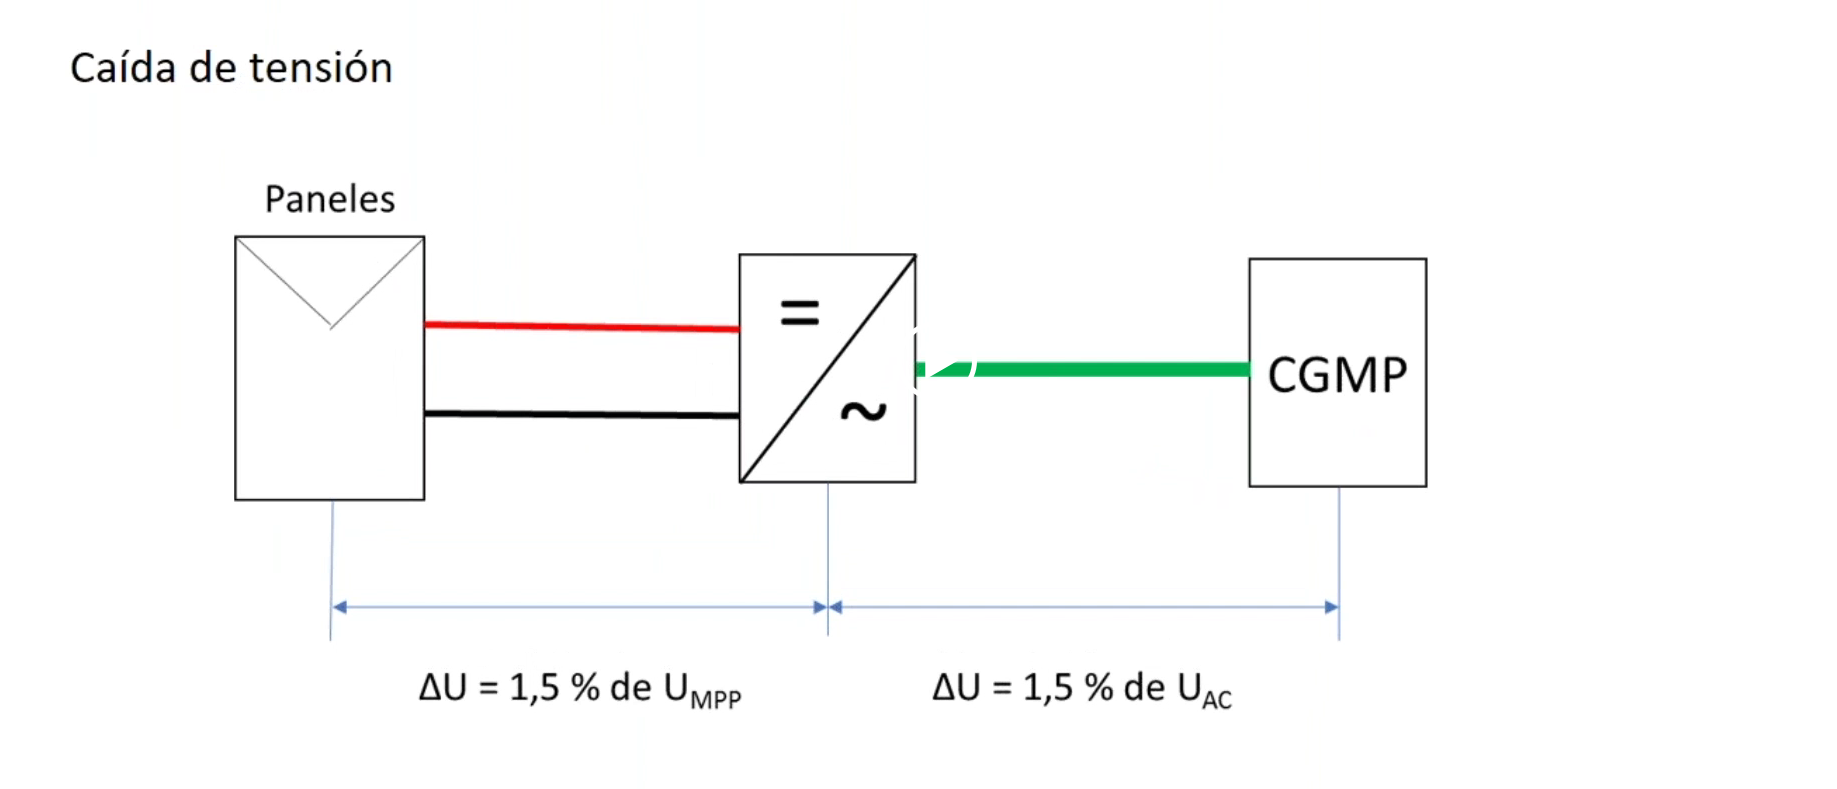

In [36]:
# ITC-BT-20 => 1.5% hasta el punto de conexion en la red publica
# Pliego de condiciones del IDAE: 1.5% desde el inversor hasta el CGMP y 1.5% en la parte de corriente continua

intensidad_string_para_calculo_A = Intensidad_Nominal_Modulo_Fotovoltaico
print(f'Intensidad del string para el calculo (Intensidad Nominal): {intensidad_string_para_calculo_A} A')

Intensidad del string para el calculo (Intensidad Nominal): 13.2 A


In [37]:
caida_tension_string_1 = (1.5/100)*Voltaje_nominal_string_1
print(f'Caida Tension String 1: {caida_tension_string_1} V')
caida_tension_string_2 = (1.5/100)*Voltaje_nominal_string_2
print(f'Caida Tension String 2: {caida_tension_string_2} V')

Caida Tension String 1: 4.887 V
Caida Tension String 2: 2.4435 V


In [38]:
# Formula Caida de Tension
# S = 2 * Longitud * Intensidad / (conductividad * caida_de_tension)
conductividad_cobre_a_temperatura_data = 45.5 # conductividad del cobre al caso mas desfavorable (90 grados celsius)
S_dc = (2 * longitud_de_cada_string_m * intensidad_string_para_calculo_A) / (conductividad_cobre_a_temperatura_data *caida_tension_string_1)
print(f'Seccion para el exterior: {S_dc} mm2 => 4 mm2 => Cable Prysun 1x4 mm2 para el lado de corriente continua')

Seccion para el exterior: 2.9681797637598746 mm2 => 4 mm2 => Cable Prysun 1x4 mm2 para el lado de corriente continua


# Caida de Tension por Intensidad Maxima Admisible (AC)



In [39]:
# Voltaje a la Salida del Inversor
Uca_V = 230 # V
Intensidad_Nominal_Inversor_A = 26.1 # A
Intensidad_para_calculo = Intensidad_Nominal_Inversor_A * 1.25 
# 1.25 de la ITC-BT-40 
# el inversor limita la intensidad, no es necesario el 1.4

print(f'Intensidad de Trabajo: {Intensidad_para_calculo} A')
Longitud_Inversor_a_CGMP_m = 15 # m
# Sistema de Instalacion B2 (multipolar bajo tubo grapado a la pared)

# En tabla de Intensidad Admisible entramos por B2, XLPE2 ( Termoestable, 2 conductores cargados)
# con 32.625 A tomamos 41 de Intensidad que nos da una seccion de 6 mm2
print(f'Seccion por Intensidad Maxima Admisible: {6} mm2 y 41 A')


Intensidad de Trabajo: 32.625 A
Seccion por Intensidad Maxima Admisible: 6 mm2 y 41 A


# Calculo de seccion por caida de tension (AC)

In [40]:
# caida de tension
caida_de_tension_ac = (1.5/100)* 230
print(f'Caida de Tension AC: {caida_de_tension_ac} V')
# se utiliza la intensidad nominal del inversor para el calculo por caida de tension 

S_ac = (2 * Longitud_Inversor_a_CGMP_m * Intensidad_Nominal_Inversor_A)/(conductividad_cobre_a_temperatura_data * caida_de_tension_ac)
print(f'Seccion por caida de tension (AC): {S_ac} mm2')
print(f'Se utiliza el inmediatamente superior:  6 mm2 > {S_ac} mm2')

Caida de Tension AC: 3.4499999999999997 V
Seccion por caida de tension (AC): 4.988055422838031 mm2
Se utiliza el inmediatamente superior:  6 mm2 > 4.988055422838031 mm2


# Criterio de cortocircuito (AC)

In [41]:
# Guia-BT-Anexo 3 => Icc = 0.8U / Zmax (20% menos de la fuente, dividido por la impedancia del bucle)

# Tomamos la resistencia del buvle a 145 grados celsius (GUIA-BT 22)
# Resistividad del Cobre a Temperatura dada
# RcuT = (1/58)*(1 + 0.00393*(T-20)) => UNE 20003 e IEC 28
Rcu150 = (1/58)*(1 + 0.00393*(145-20)) # mm2 * Ohmio / m

# resistencia de bucle
Resistencia_Bucle = 2 * Rcu150 * Longitud_Inversor_a_CGMP_m / S_ac

# intensidad de cortocircuito minima
Iccmin = 0.8 * 230 / Resistencia_Bucle

# se debe cumplir Iccmin > Im = 10*In (proteccion curva C) GUIA-BT-22, pto. 1.1


print(f' {Iccmin} > 320 A = 10 * 32 => se garantiza la proteccion de cortocircuito con 32 A')
print('la seccion de 6 cumple el criterio de cortocircuito')
print('Solucion: Afumex class 1000V (AS) de 3G6')

 1189.8860569438943 > 320 A = 10 * 32 => se garantiza la proteccion de cortocircuito con 32 A
la seccion de 6 cumple el criterio de cortocircuito
Solucion: Afumex class 1000V (AS) de 3G6
